#Vision AI Project

##Pre-requisite

###Download asl data from Kaggel

In [ ]:
# =========================
# 1) Install packages
# =========================
!pip install -q kaggle transformers torch torchvision scikit-learn pillow tqdm matplotlib
!pip install gTTS

# =========================
# 2) Upload kaggle.json
# =========================
from google.colab import files
uploaded = files.upload()   # choose kaggle.json from your local machine

# =========================
# 3) Configure Kaggle API
# =========================
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# optional sanity check
!kaggle datasets list -s asl | head

# =========================
# 4) Download dataset from Kaggle
# =========================
!kaggle datasets download -d grassknoted/asl-alphabet -p /content/

# =========================
# 5) Unzip dataset
# =========================
!mkdir -p /content/asl_alphabet
!unzip -q /content/asl-alphabet.zip -d /content/asl_alphabet

# =========================
# 6) Inspect folder structure
# =========================
import os

for root, dirs, files_ in os.walk("/content/asl_dataset"):
    print(root)
    print("  subdirs:", dirs[:10])
    print("  files:", files_[:5])
    print("-" * 60)
    # limit deep printing
    if root.count(os.sep) > 3:
        continue

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


Saving kaggle.json to kaggle.json
ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
grassknoted/asl-alphabet                                        ASL Alphabet                                         1100887034  2018-04-22 19:31:36.210000         118610       1264  0.875            
lexset/synthetic-asl-alphabet                                   Synthetic ASL Alphabet                               7067002276  2022-06-17 20:36:37.220000           5587         57  0.9375           
abd0kamel/asl-citizen                                           ASL Citizen                                         45964957208  2023-12-17 02:57:44.597000       

In [ ]:
# =========================
# Auto-detect train folder
# =========================
import os

def looks_like_class_folder(path):
    if not os.path.isdir(path):
        return False
    subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    if len(subdirs) < 2:
        return False
    # check whether several subdirs contain image files
    image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    hits = 0
    for d in subdirs[:10]:
        subpath = os.path.join(path, d)
        files = os.listdir(subpath)
        if any(f.lower().endswith(image_exts) for f in files):
            hits += 1
    return hits >= 2

candidates = []
for root, dirs, files_ in os.walk("/content/asl_dataset"):
    if looks_like_class_folder(root):
        candidates.append(root)

print("Possible ImageFolder roots:")
for c in candidates:
    print(" -", c)

DATA_DIR = candidates[0] if candidates else "/content/asl_dataset"
print("\nUsing DATA_DIR =", DATA_DIR)

Possible ImageFolder roots:

Using DATA_DIR = /content/asl_dataset


In [ ]:
!unzip -oq /content/asl-alphabet.zip -d /content/asl_alphabet

In [ ]:
import os

for root, dirs, files in os.walk("/content/asl_alphabet"):
    if "A" in dirs and "B" in dirs and "C" in dirs:
        print("USE THIS DATA_DIR:", root)

USE THIS DATA_DIR: /content/asl_alphabet/asl_alphabet_train/asl_alphabet_train


## Clip Traning using GPU

In [ ]:
!ls -R /content/asl_alphabet/asl_alphabet_train/asl_alphabet_train | head -n 100

/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train:
A
B
C
D
del
E
F
G
H
I
J
K
L
M
N
nothing
O
P
Q
R
S
space
T
U
V
W
X
Y
Z

/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train/A:
A1000.jpg
A1001.jpg
A1002.jpg
A1003.jpg
A1004.jpg
A1005.jpg
A1006.jpg
A1007.jpg
A1008.jpg
A1009.jpg
A100.jpg
A1010.jpg
A1011.jpg
A1012.jpg
A1013.jpg
A1014.jpg
A1015.jpg
A1016.jpg
A1017.jpg
A1018.jpg
A1019.jpg
A101.jpg
A1020.jpg
A1021.jpg
A1022.jpg
A1023.jpg
A1024.jpg
A1025.jpg
A1026.jpg
A1027.jpg
A1028.jpg
A1029.jpg
A102.jpg
A1030.jpg
A1031.jpg
A1032.jpg
A1033.jpg
A1034.jpg
A1035.jpg
A1036.jpg
A1037.jpg
A1038.jpg
A1039.jpg
A103.jpg
A1040.jpg
A1041.jpg
A1042.jpg
A1043.jpg
A1044.jpg
A1045.jpg
A1046.jpg
A1047.jpg
A1048.jpg
A1049.jpg
A104.jpg
A1050.jpg
A1051.jpg
A1052.jpg
A1053.jpg
A1054.jpg
A1055.jpg
A1056.jpg
A1057.jpg
A1058.jpg
A1059.jpg
A105.jpg
A1060.jpg
A1061.jpg


In [ ]:
from torchvision.datasets import ImageFolder
import shutil
import os

DATA_DIR = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"

dataset = ImageFolder(DATA_DIR)

print(dataset.classes)
print(len(dataset.classes))



['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
29


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Num classes: 29


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Train Loss: 0.0005 | Train Acc: 0.9999 | Train F1: 0.9999
Val   Loss: 0.0005 | Val   Acc: 0.9999 | Val   F1: 0.9999

Epoch 13/15


Train Loss: 0.0007 | Train Acc: 0.9999 | Train F1: 0.9999
Val   Loss: 0.0003 | Val   Acc: 0.9999 | Val   F1: 0.9999

Epoch 14/15


Train Loss: 0.0003 | Train Acc: 0.9999 | Train F1: 0.9999
Val   Loss: 0.0002 | Val   Acc: 0.9999 | Val   F1: 0.9999

Epoch 15/15


Train Loss: 0.0003 | Train Acc: 0.9999 | Train F1: 0.9999
Val   Loss: 0.0003 | Val   Acc: 0.9999 | Val   F1: 0.9999



Final Validation Results
Accuracy: 0.9999
Weighted F1: 0.9999

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       576
           C       1.00      1.00      1.00       584
           D       1.00      1.00      1.00       575
           E       1.00      1.00      1.00       645
           F       1.00      1.00      1.00       617
           G       1.00      1.00      1.00       626
           H       1.00      1.00      1.00       592
           I       1.00      1.00      1.00       577
           J       1.00      1.00      1.00       607
           K       1.00      1.00      1.00       550
           L       1.00      1.00      1.00       604
           M       1.00      1.00      1.00       603
           N       1.00      1.00      1.00       584
           O       1.00      1.00      1.00       618
           P       1.00      1.00      1.00     

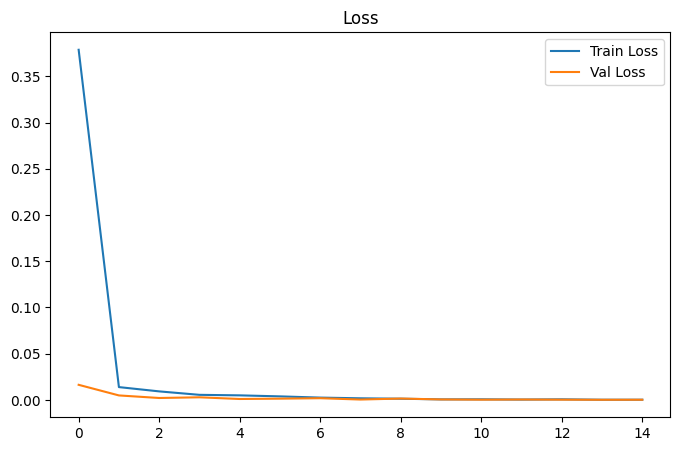

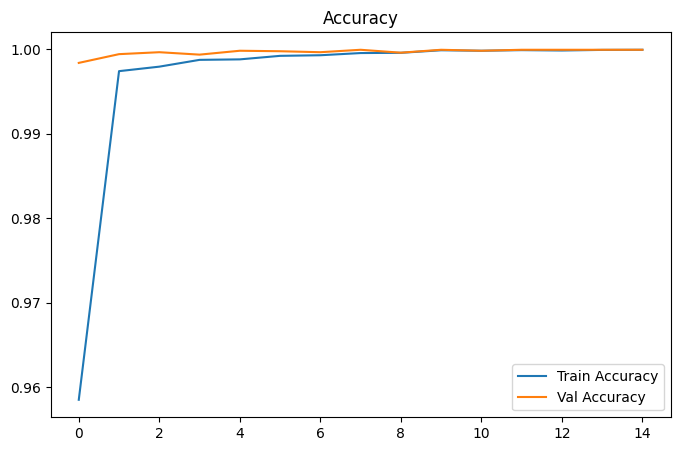

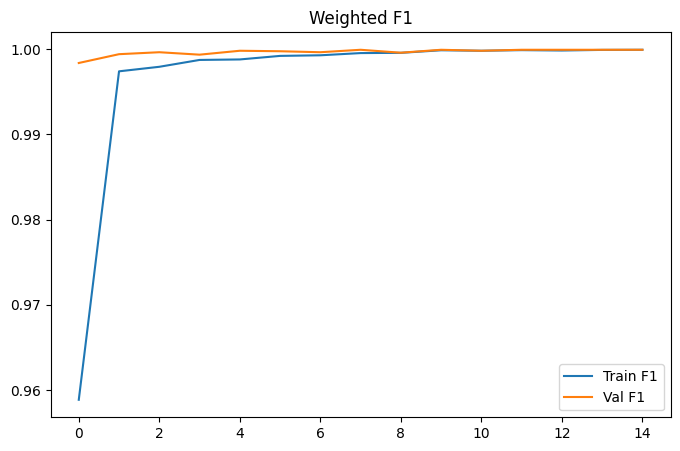

In [ ]:
import os
import copy
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Dataset
from torchvision.datasets import ImageFolder
from torchvision import transforms

from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =========================================================
# 1. SETTINGS
# =========================================================
DATA_DIR = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"   # change if needed
MODEL_NAME = "openai/clip-vit-base-patch32"
LAYERS_TO_UNFREEZE = -6

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR_HEAD = 1e-3
LR_BACKBONE = 5e-6
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.2
NUM_WORKERS = 2
MODEL_SAVE_PATH = "/content/best_clip_asl_ft.pth"

# =========================================================
# 2. SEED
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# 3. VERIFY DATASET ROOT
# =========================================================
full_dataset_raw = ImageFolder(DATA_DIR)
print("Classes:", full_dataset_raw.classes)
print("Num classes:", len(full_dataset_raw.classes))

if "asl_dataset" in full_dataset_raw.classes:
    raise ValueError("Wrong DATA_DIR. 'asl_dataset' is showing up as a class.")

class_names = full_dataset_raw.classes
num_classes = len(class_names)

# =========================================================
# 4. TRAIN / VAL SPLIT
# =========================================================
val_size = int(len(full_dataset_raw) * VAL_SPLIT)
train_size = len(full_dataset_raw) - val_size

train_subset, val_subset = random_split(
    full_dataset_raw,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# =========================================================
# 5. TRANSFORMS
# =========================================================
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_size = processor.image_processor.size["shortest_edge"] if "shortest_edge" in processor.image_processor.size else 224

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop((clip_size, clip_size), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_processor.image_mean,
        std=processor.image_processor.image_std
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((clip_size, clip_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_processor.image_mean,
        std=processor.image_processor.image_std
    )
])

# =========================================================
# 6. WRAPPED DATASET WITH TRANSFORMS
# =========================================================
class WrappedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        img = img.convert("RGB")
        img = self.transform(img)
        return img, label

train_dataset = WrappedSubset(train_subset, train_tfms)
val_dataset = WrappedSubset(val_subset, val_tfms)

# =========================================================
# 7. WEIGHTED SAMPLER
# =========================================================
train_labels = [train_subset[i][1] for i in range(len(train_subset))]
class_counts = Counter(train_labels)

sample_weights = [1.0 / class_counts[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# =========================================================
# 8. MODEL: PARTIAL FINE-TUNING
# =========================================================
class CLIPFineTuneClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.clip.config.projection_dim, num_classes)
        )

        # Freeze everything first
        for p in self.clip.parameters():
            p.requires_grad = False

        # Unfreeze visual projection
        for p in self.clip.visual_projection.parameters():
            p.requires_grad = True

        # Unfreeze last 2 transformer layers of vision encoder
        for layer in self.clip.vision_model.encoder.layers[-6:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Unfreeze final layer norm
        for p in self.clip.vision_model.post_layernorm.parameters():
            p.requires_grad = True

    def forward(self, pixel_values):
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.clip.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits

model = CLIPFineTuneClassifier(MODEL_NAME, num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()

head_params = list(model.classifier.parameters())
backbone_params = []
for name, p in model.named_parameters():
    if p.requires_grad and not name.startswith("classifier"):
        backbone_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": head_params, "lr": LR_HEAD},
        {"params": backbone_params, "lr": LR_BACKBONE},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# =========================================================
# 9. TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    return epoch_loss, epoch_acc, epoch_f1

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

# =========================================================
# 10. TRAIN LOOP
# =========================================================
best_val_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")

    # if val_f1 > best_val_f1:
    #     best_val_f1 = val_f1
    #     best_model_wts = copy.deepcopy(model.state_dict())
    #     torch.save(best_model_wts, MODEL_SAVE_PATH)
    #     print("Best model saved.")

    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      best_model_wts = copy.deepcopy(model.state_dict())

      torch.save({
          "model_state": best_model_wts,
          "class_names": class_names,
          "config": {
              "model_name": MODEL_NAME,
              "num_classes": num_classes,
              "clip_size": clip_size,
              "layers_to_unfreeze": LAYERS_TO_UNFREEZE
          },
          "metrics": {
              "val_f1": val_f1
          }
      }, MODEL_SAVE_PATH)

      print("Best model saved.")

model.load_state_dict(best_model_wts)

# =========================================================
# 11. FINAL REPORT
# =========================================================
val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader)

print("\nFinal Validation Results")
print("Accuracy:", round(val_acc, 4))
print("Weighted F1:", round(val_f1, 4))

unique_labels = np.unique(y_true)
unique_class_names = [class_names[i] for i in unique_labels]

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=unique_labels,
    target_names=unique_class_names
))

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.legend()
plt.title("Weighted F1")
plt.show()

In [ ]:
MODEL_PATH = "/content/best_clip_asl_ft.pth"

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Using image:", image_path)

IndexError: list index out of range

In [ ]:
import torch
import torch.nn as nn
from PIL import Image
from transformers import CLIPModel
from torchvision.datasets import ImageFolder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-base-patch32"
MODEL_PATH = "/content/best_clip_asl_ft.pth"



DATA_DIR = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"
dataset = ImageFolder(DATA_DIR)

class_names = dataset.classes
print("Classes:", class_names)

class CLIPFineTuneClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(self.clip.config.projection_dim, num_classes)
        )

    def forward(self, pixel_values):
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.clip.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits
model = CLIPFineTuneClassifier(MODEL_NAME, len(class_names))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded ✅")

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])


import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

input_tensor = transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(input_tensor)
    pred = torch.argmax(logits, dim=1).item()

pred_label = class_names[pred]

print("Predicted:", pred_label)

##Image prediction

###Upload image -> predict sign -> pronounce word

In [ ]:
!pip install -q transformers torch torchvision pillow gtts

In [ ]:
import torch
import torch.nn as nn
from PIL import Image
from transformers import CLIPModel
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-base-patch32"
MODEL_PATH = "/content/best_clip_asl_ft.pth"

DATA_DIR = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"
dataset = ImageFolder(DATA_DIR)

class_names = dataset.classes


# your class names (must match training order)
#class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

# Model
class CLIPFineTuneClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(self.clip.config.projection_dim, num_classes)
        )

    def forward(self, pixel_values):
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        image_features = self.clip.visual_projection(pooled_output)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        logits = self.classifier(image_features)
        return logits


checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

class_names = checkpoint["class_names"]
print("Classes:", class_names)
print("Number of classes:", len(class_names))

model = CLIPFineTuneClassifier(MODEL_NAME, len(class_names))

model.load_state_dict(checkpoint["model_state"])

model.to(DEVICE)
model.eval()

print("Model loaded successfully ✅")



Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Number of classes: 29


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully ✅


In [ ]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


Saving hand1_u_left_seg_2_cropped.jpeg to hand1_u_left_seg_2_cropped.jpeg
Uploaded: hand1_u_left_seg_2_cropped.jpeg


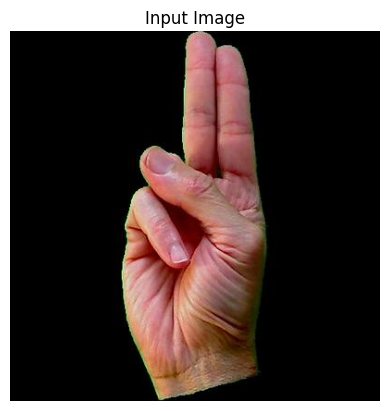

Predicted Letter : U
Speech: Predicted sign is letter U


In [ ]:
from torchvision import transforms
from google.colab import files
from gtts import gTTS
from IPython.display import Audio

uploaded = files.upload()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

# Get uploaded file name
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)

image = Image.open(image_path).convert("RGB")

import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

input_tensor = transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(input_tensor)
    pred = torch.argmax(logits, dim=1).item()

pred_label = class_names[pred]

print("Predicted Letter :", pred_label)



if pred_label.isdigit():
    spoken_text = f"Predicted sign is number {digit_map[pred_label]}"
else:
    spoken_text = f"Predicted sign is letter {pred_label.upper()}"

print("Speech:", spoken_text)

tts = gTTS(text=spoken_text, lang="en")
tts.save("output.mp3")

Audio("output.mp3", autoplay=True)



In [ ]:
MODEL_PATH = "/content/best_clip_asl_ft.pth"
from google.colab import files
files.download("/content/best_clip_asl_ft.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import Counter

labels = [full_dataset_raw[i][1] for i in range(len(full_dataset_raw))]
class_counts = Counter(labels)

for idx, count in class_counts.items():
    print(f"{full_dataset_raw.classes[idx]}: {count}")

A: 3000
B: 3000
C: 3000
D: 3000
E: 3000
F: 3000
G: 3000
H: 3000
I: 3000
J: 3000
K: 3000
L: 3000
M: 3000
N: 3000
O: 3000
P: 3000
Q: 3000
R: 3000
S: 3000
T: 3000
U: 3000
V: 3000
W: 3000
X: 3000
Y: 3000
Z: 3000
del: 3000
nothing: 3000
space: 3000


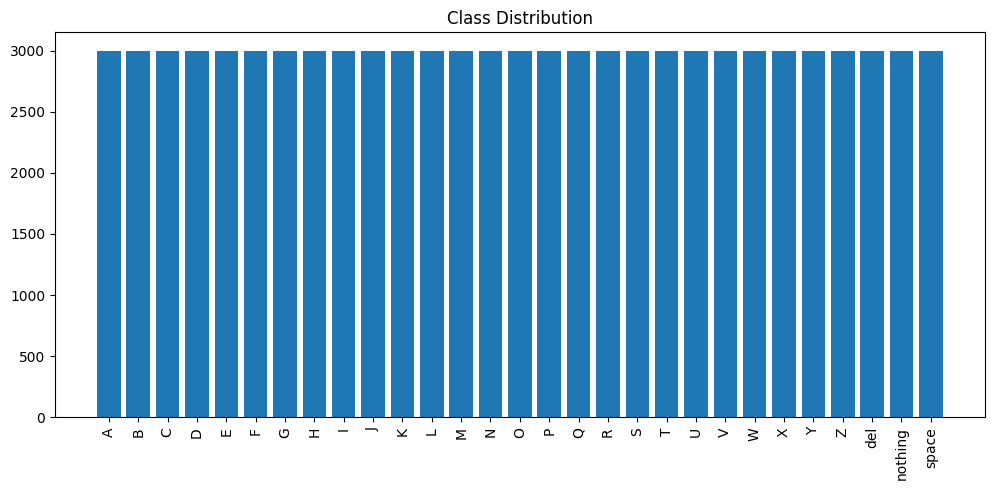

In [ ]:
import matplotlib.pyplot as plt

counts = [class_counts[i] for i in range(len(full_dataset_raw.classes))]

plt.figure(figsize=(12,5))
plt.bar(full_dataset_raw.classes, counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()